# **1. Import Library dan Persiapan Awal**

In [76]:

# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import os
import io
import re
import joblib
import warnings
import time
import nbformat
from google.colab import files
warnings.filterwarnings('ignore')

print("Seluruh pustaka dependensi komputasi berhasil dimuat ke dalam sistem.")

Seluruh pustaka dependensi komputasi berhasil dimuat ke dalam sistem.


# **2. Memuat dan Mempersiapkan Dataset**

In [50]:
warnings.filterwarnings('ignore')

print("\n=== TAHAPAN DATA LOADING & ENHANCED PREPROCESSING ===")
start_time = time.time ()
# PROSES UPLOAD FILE
print("\nSilakan upload file dataset Anda...")
uploaded = files.upload()

# Load Dataset ke Pandas Dataframe menggunakan BytesIO
df_raw = pd.read_excel(io.BytesIO(list(uploaded.values())[0]))

# Standarisasi Nama Kolom Target Utama
if "Unnamed: 0" in df_raw.columns:
    df_raw.rename(columns={"Unnamed: 0": "judul_skripsi"}, inplace=True)
elif df_raw.columns[0] != "judul_skripsi":
    df_raw.rename(columns={df_raw.columns[0]: "judul_skripsi"}, inplace=True)

print(f"\nBerhasil memuat dataset awal dengan {len(df_raw)} judul skripsi.")

# DICTIONARY NORMALISASI ISTILAH AKADEMIK & PTIK
normalization_dict = {
    r'\bsmk\s+n\s+': 'smk negeri ',
    r'\bsma\s+n\s+': 'sma negeri ',
    r'\bsmp\s+n\s+': 'smp negeri ',
    r'\bsd\s+n\s+': 'sd negeri ',
    r'\btkj\b': 'teknik komputer jaringan',
    r'\brpl\b': 'rekayasa perangkat lunak',
    r'\bkkpi\b': 'keterampilan komputer pengelolaan informasi',
    r'\btik\b': 'teknologi informasi komunikasi',
    r'\be-learning\b': 'elearning',
    r'\be-commerce\b': 'ecommerce',
    r'\be-government\b': 'egovernment',
    r'\be-marketplace\b': 'emarketplace',
    r'\be-modul\b': 'emodul',
    r'\be-library\b': 'elibrary',
    r'\be-business\b': 'ebusiness',
    r'\bweb-based\b': 'webbased',
    r'\bweb\s+based\b': 'webbased',
    r'\bclient-server\b': 'clientserver',
    r'student\s+team\s+achievement\s+division': 'stad',
    r'team\s+assisted\s+individualization': 'tai',
    r'problem\s+based\s+learning': 'pbl',
    r'project\s+based\s+learning': 'pjbl',
    r'sistem\s+informasi': 'sisteminformasi',
    r'basis\s+data': 'basisdata',
    r'data\s+warehouse': 'datawarehouse',
    r'business\s+intelligence': 'businessintelligence',
    r'kecerdasan\s+buatan': 'kecerdasanbuatan',
    r'jaringan\s+komputer': 'jaringankomputer',
    r'desain\s+grafis': 'desaingrafis',
    r'desain\s+komunikasi\s+visual': 'dkv',
}

important_terms = [
    '2d', '3d', '5g', '4g', 'web 2.0', 'web 3.0', 'industri 4.0',
    'iot', 'html5', 'css3', 'php7', 'ipv6', 'wifi', 'qt5', 'dotnet',
    'opencv', 'bootstrap4', 'html5css3', 'php8', 'python3', 'win32',
    '32bit', '64bit', 'x86', 'arduino', 'raspberry', 'unity3d', 'ue4'
]

# PREPROCESSING TEKS
def enhanced_preprocessing(text):
    text = str(text).lower().strip()

    # Proteksi istilah penting menggunakan placeholder numerik
    placeholders = {}
    for i, term in enumerate(important_terms):
        if term in text:
            placeholder = f" PROTERM{i} "
            placeholders[placeholder] = term
            text = text.replace(term, placeholder)

    # Standardisasi istilah berdasarkan dictionary regex
    for pattern, replacement in normalization_dict.items():
        text = re.sub(pattern, replacement, text)

    # Deteksi singkatan sekolah numerik (misal: SMK 1 -> smk negeri 1)
    school_patterns = r'\b(smk|sma|smp|sd)\s+(\d+)\b'
    text = re.sub(school_patterns, lambda m: f"{m.group(1)} negeri {m.group(2)}", text)

    # Pembersihan karakter khusus (menjaga alfabet dan angka dalam placeholder)
    text = re.sub(r'[^\w\s]', ' ', text)

    # Hapus angka yang berdiri sendiri di luar korpus placeholder penting
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Kembalikan istilah penting dari placeholder ke bentuk murninya
    for placeholder, term in placeholders.items():
        text = text.replace(placeholder.strip(), term)

    return text.strip()

# FUNGSI PENANGANAN DUPLIKASI DATA
def handle_duplicates(dataframe, threshold=0.9):
    print("\n[Proses] Mendeteksi dan mengeliminasi duplikasi judul skripsi...")

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(dataframe['judul_clean'])
    similarity_matrix = cosine_similarity(tfidf_matrix)

    duplicate_indices = []
    duplicate_pairs = []

    for i in range(len(similarity_matrix)):
        for j in range(i+1, len(similarity_matrix)):
            if similarity_matrix[i][j] > threshold:
                duplicate_pairs.append((i, j, similarity_matrix[i][j]))
                duplicate_indices.append(j)

    duplicate_indices = list(set(duplicate_indices))
    print(f" -> Menemukan {len(duplicate_indices)} judul duplikat dengan batas ambang kemiripan {threshold*100}%")

    if len(duplicate_pairs) > 0:
        print("\nContoh judul yang terdeteksi mirip/duplikat:")
        for i, j, sim in duplicate_pairs[:3]:
            print(f" -> Nilai Kemiripan: {sim:.4f}")
            print(f"    Judul A: {dataframe['judul_skripsi'].iloc[i]}")
            print(f"    Judul B: {dataframe['judul_skripsi'].iloc[j]}")
            print("-" * 40)

    # Drop duplikat dan langsung lakukan reset indeks murni
    df_clean_result = dataframe.drop(duplicate_indices).reset_index(drop=True)
    print(f" -> Ukuran data awal : {len(dataframe)} baris")
    print(f" -> Ukuran data bersih: {len(df_clean_result)} baris")
    return df_clean_result

# FUNGSI EKSTRAKSI FITUR TAMBAHAN
def add_custom_features(dataframe):
    print("\n[Proses] Menambahkan fitur metrik tambahan untuk analisis deskriptif...")

    dataframe['word_count'] = dataframe['judul_clean'].apply(lambda x: len(str(x).split()))

    methodology_patterns = [r'pengaruh', r'hubungan', r'korelasi', r'komparasi', r'perbandingan',
                            r'penerapan', r'implementasi', r'analisis', r'efektivitas', r'pengembangan']
    dataframe['contains_methodology'] = dataframe['judul_clean'].apply(
        lambda x: 1 if any(re.search(r'\b' + p + r'\b', x) for p in methodology_patterns) else 0
    )

    media_patterns = [r'video', r'tutorial', r'game', r'multimedia', r'media interaktif',
                      r'aplikasi', r'mobile', r'android', r'website', r'web', r'elearning']
    dataframe['contains_media'] = dataframe['judul_clean'].apply(
        lambda x: 1 if any(re.search(r'\b' + p + r'\b', x) for p in media_patterns) else 0
    )

    model_patterns = [r'pembelajaran', r'model', r'metode', r'teknik', r'strategi',
                      r'stad', r'jigsaw', r'discovery', r'tgt', r'tai', r'pbl', r'pjbl']
    dataframe['contains_learning_model'] = dataframe['judul_clean'].apply(
        lambda x: 1 if any(re.search(r'\b' + p + r'\b', x) for p in model_patterns) else 0
    )

    return dataframe


df_raw['judul_clean'] = df_raw['judul_skripsi'].apply(enhanced_preprocessing)

# Eksekusi standar (Mencari duplikat & mengekstrak metrik pendukung Bab IV)
df_cleaned = handle_duplicates(df_raw, threshold=0.9)
df_final = add_custom_features(df_cleaned)

print("\n✔ Selesai! Contoh 3 baris data acak hasil preprocessing:")
sample_indices = np.random.choice(len(df_final), min(3, len(df_final)), replace=False)
for idx in sample_indices:
    print(f" Asli : {df_final['judul_skripsi'].iloc[idx]}")
    print(f" Bersih: {df_final['judul_clean'].iloc[idx]}")
    print("-" * 50)

df = df_final.copy()


=== TAHAPAN DATA LOADING & ENHANCED PREPROCESSING ===

Silakan upload file dataset Anda...


Saving judulskripsi.xlsx to judulskripsi (3).xlsx

Berhasil memuat dataset awal dengan 950 judul skripsi.

[Proses] Mendeteksi dan mengeliminasi duplikasi judul skripsi...
 -> Menemukan 27 judul duplikat dengan batas ambang kemiripan 90.0%

Contoh judul yang terdeteksi mirip/duplikat:
 -> Nilai Kemiripan: 0.9840
    Judul A: Pengaruh Metode Pembelajaran Demonstrasi Terhadap Hasil Belajar Jaringan Dasar Siswa Kelas X SMK Negeri 2 Bitung
    Judul B: PENGARUH METODE DEMONSTRASI TERHADAP HASIL BELAJAR JARINGAN DASAR SISWA KELAS X SMK NEGERI 5 BITUNG
----------------------------------------
 -> Nilai Kemiripan: 1.0000
    Judul A: PENERAPAN PEMBELAJARAN BERBASIS MULTIMEDIA UNTUK MENINGKATKAN HASIL BELAJAR SIMULASI DIGITAL KELAS X SMK NEGERI 1 AMURANG
    Judul B: PENERAPAN PEMBELAJARAN BERBASIS MULTIMEDIA UNTUK MENINGKATKAN HASIL BELAJAR SIMULASI DIGITAL KELAS X SMK NEGERI 1 AMURANG
----------------------------------------
 -> Nilai Kemiripan: 1.0000
    Judul A: PENGARUH PENGGUNAAN VIDEO 

# **3. Eksplorasi Data**


=== ANALISIS DISTRIBUSI PANJANG TEKS (WORD COUNT) ===


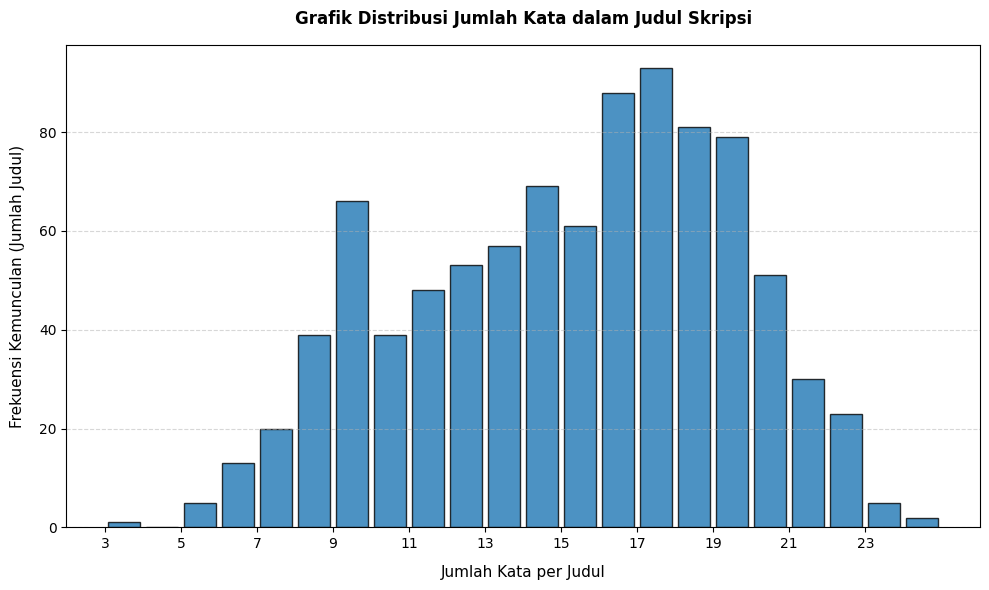


Statistik Deskriptif Jumlah Kata dalam Judul (N = 923):
 -> Rata-rata (Mean) : 14.73 kata
 -> Nilai Tengah (Median): 15.0 kata
 -> Paling Sedikit (Min) : 3 kata
 -> Paling Banyak (Max)  : 24 kata


In [51]:
print("\n=== ANALISIS DISTRIBUSI PANJANG TEKS (WORD COUNT) ===")

df_cleaned = df.drop_duplicates(subset=['judul_skripsi']).reset_index(drop=True)

# Hitung jumlah kata dalam judul
df_cleaned['word_count'] = df_cleaned['judul_clean'].apply(lambda x: len(str(x).split()))

# VISUALISASI HISTOGRAM
plt.figure(figsize=(10, 6), dpi=100)
n, bins, patches = plt.hist(df_cleaned['word_count'], bins=range(df_cleaned['word_count'].min(), df_cleaned['word_count'].max() + 2),
                            color='#1f77b4', edgecolor='black', alpha=0.8, rwidth=0.85)

plt.title('Grafik Distribusi Jumlah Kata dalam Judul Skripsi', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Jumlah Kata per Judul', fontsize=11, labelpad=10)
plt.ylabel('Frekuensi Kemunculan (Jumlah Judul)', fontsize=11, labelpad=10)

# Mengatur agar sumbu X menampilkan angka genap/pas sesuai rentang kata
plt.xticks(np.arange(df_cleaned['word_count'].min(), df_cleaned['word_count'].max() + 1, 2))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menyimpan gambar beresolusi tinggi ke folder output
os.makedirs('output', exist_ok=True)
plt.savefig('output/distribusi_jumlah_kata.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# CETAK STATISTIK DESKRIPTIF UNTUK PARAGRAF ANALISIS DI WORD
print(f"\nStatistik Deskriptif Jumlah Kata dalam Judul (N = {len(df_cleaned)}):")
print(f" -> Rata-rata (Mean) : {df_cleaned['word_count'].mean():.2f} kata")
print(f" -> Nilai Tengah (Median): {df_cleaned['word_count'].median()} kata")
print(f" -> Paling Sedikit (Min) : {df_cleaned['word_count'].min()} kata")
print(f" -> Paling Banyak (Max)  : {df_cleaned['word_count'].max()} kata")

df = df_cleaned.copy()

# **4. Pelabelan Otomatis Berdasarkan Kata Kunci**


=== PROSES PELABELAN OTOMATIS BERDASARKAN BIDANG KONSENTRASI ===

Distribusi Bidang Konsentrasi (Murni 923 Data):
 TKJ: 368 judul (39.87%)
 RPL: 363 judul (39.33%)
 MULTIMEDIA: 192 judul (20.80%)


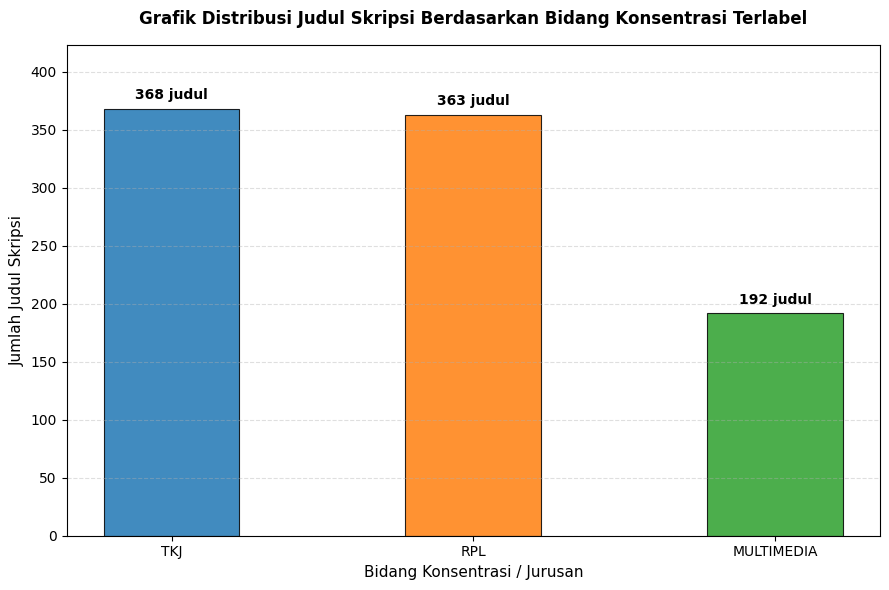


Statistik Jumlah Kata Berdasarkan Bidang Konsentrasi:
                 mean  median  min  max
label                                  
MULTIMEDIA  13.187500    13.5    6   23
RPL         13.826446    14.0    5   23
TKJ         16.423913    17.0    3   24


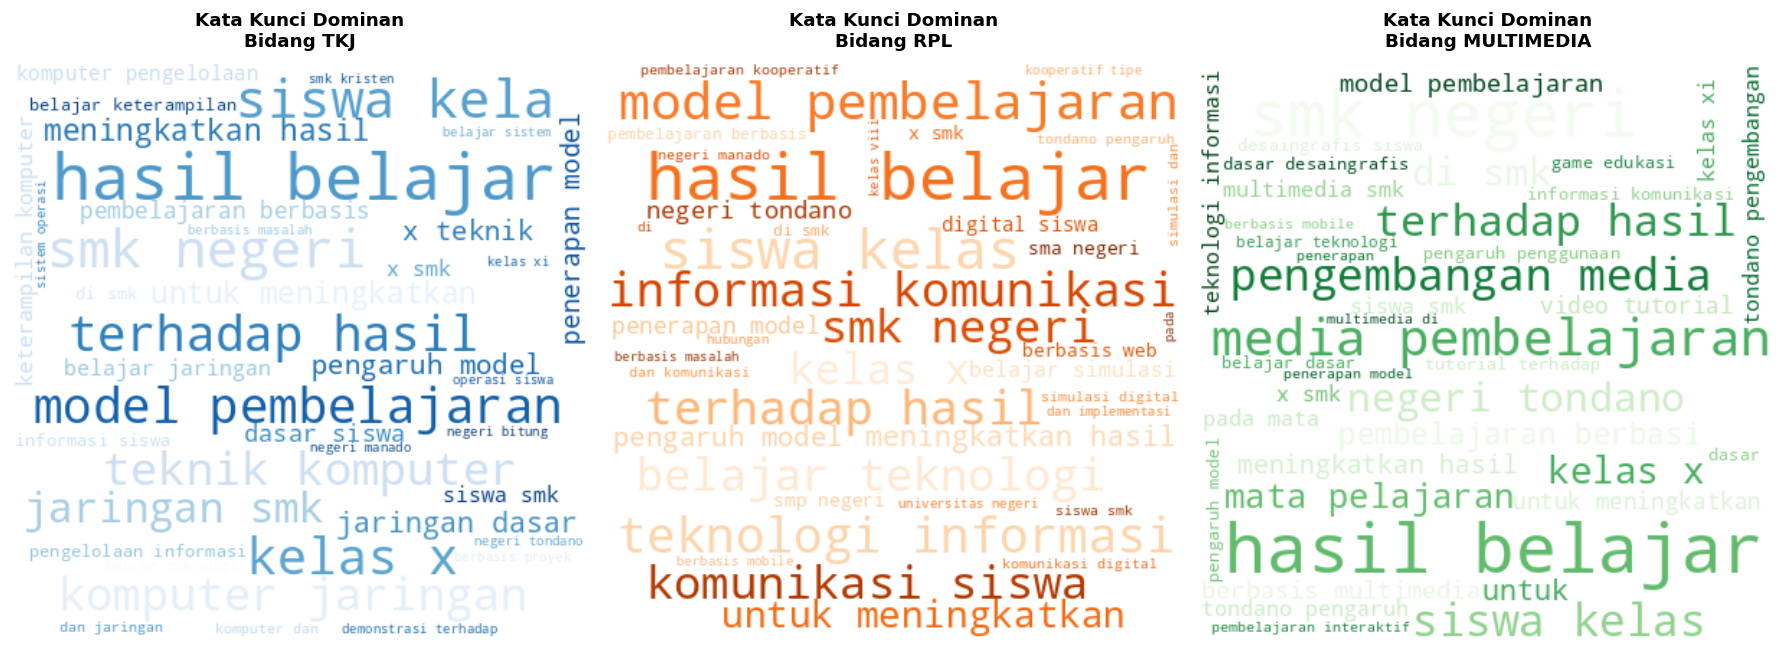

In [52]:
print("\n=== PROSES PELABELAN OTOMATIS BERDASARKAN BIDANG KONSENTRASI ===")

# Gunakan data murni (923 judul) hasil eliminasi duplikat
df_cleaned = df.drop_duplicates(subset=['judul_skripsi']).reset_index(drop=True)

# Fungsi pelabelan otomatis berdasarkan kata kunci dengan pembobotan
def assign_label(title):
    title_lower = str(title).lower().strip()

    # Kata kunci untuk RPL dengan pembobotan
    rpl_keywords = {
        'sistem informasi': 3, 'perancangan sistem': 3, 'aplikasi': 2, 'web': 2,
        'android': 2, 'perangkat lunak': 3, 'basis data': 3, 'database': 3,
        'website': 2, 'mobile': 2, 'e-learning': 2, 'e-commerce': 3,
        'pemrograman': 3, 'e-': 1, 'rancang bangun': 3, 'sistem pendukung keputusan': 3,
        'business intelligence': 3, 'perpustakaan': 2, 'akademik': 1,
        'implementasi sistem': 3, 'cms': 3, 'repository': 2, 'informasi': 1,
        'data warehouse': 3, 'pengembangan aplikasi': 3, 'perancangan aplikasi': 3,
        'sistem manajemen': 3, 'sistem administrasi': 3, 'aplikasi mobile': 3
    }

    # Ubah kata kunci pembobotan fokus ke istilah TKJ / Jaringan
    network_keywords = {
        'jaringan': 3, 'network': 3, 'wireless': 3, 'lan': 3, 'wan': 3, 'server': 2,
        'router': 3, 'topologi': 3, 'vlan': 3, 'mikrotik': 3, 'bandwidth': 3,
        'monitoring jaringan': 3, 'keamanan jaringan': 3, 'protokol': 2,
        'infrastruktur jaringan': 3, 'administrasi jaringan': 3, 'voip': 3,
        'virtualisasi': 2, 'cloud': 2, 'sistem operasi': 1, 'merakit komputer': 3,
        'perakitan komputer': 3, 'instalasi jaringan': 3, 'qos': 3, 'hotspot': 3,
        'teknologi jaringan': 3, 'teknik komputer': 2, 'teknik jaringan': 3,
        'tkj': 3, 'administrasi server': 3, 'internet': 1
    }

    # Kata kunci untuk Multimedia dengan pembobotan
    multimedia_keywords = {
        'multimedia': 3, 'game': 3, 'animasi': 3, 'grafis': 3, 'desain grafis': 3,
        'visual': 2, 'audio': 2, 'video': 2, 'fotografi': 3, 'augmented reality': 3,
        'virtual reality': 3, 'game edukasi': 3, 'interaktif': 2, 'desain komunikasi visual': 3,
        'media pembelajaran': 2, '3d': 2, '2d': 2, 'dkv': 3, 'user interface': 3,
        'editing': 2, 'rendering': 3, 'motion graphic': 3, 'film': 2, 'dokumenter': 2,
        'tutorial': 1, 'video tutorial': 2, 'media interaktif': 3, 'game berbasis': 3,
        'edukasi': 1, 'pembelajaran interaktif': 2, 'pemodelan': 2
    }

    # Hitung kemunculan kata kunci dengan pembobotan
    rpl_score = 0
    network_score = 0
    multimedia_score = 0

    # Hitung skor untuk RPL
    for keyword, weight in rpl_keywords.items():
        if keyword in title_lower:
            rpl_score += weight

    # Hitung skor untuk Jaringan/TKJ
    for keyword, weight in network_keywords.items():
        if keyword in title_lower:
            network_score += weight

    # Hitung skor untuk Multimedia
    for keyword, weight in multimedia_keywords.items():
        if keyword in title_lower:
            multimedia_score += weight

    # Penanganan khusus kata kunci kuat
    if any(x in title_lower for x in ['basis data', 'database', 'data warehouse', 'sistem informasi']):
        rpl_score += 2

    if any(x in title_lower for x in ['administrasi server', 'administrasi infrastruktur', 'local area network', 'jaringan komputer']):
        network_score += 2

    if any(x in title_lower for x in ['desain komunikasi visual', 'dkv', 'animasi 3d']):
        multimedia_score += 2

    # Penanganan kata "pembelajaran" yang ambigu
    if 'pembelajaran' in title_lower and not any(special in title_lower for special in
                                                ['media pembelajaran', 'multimedia pembelajaran',
                                                 'game', 'animasi', 'visual', 'interaktif']):
        multimedia_score -= 1

    # Penanganan untuk model pembelajaran
    if any(model in title_lower for model in ['model pembelajaran', 'metode pembelajaran']):
        if any(subject in title_lower for subject in ['tkj', 'jaringan', 'komputer', 'sistem operasi']):
            network_score += 2
        elif any(subject in title_lower for subject in ['multimedia', 'grafis', 'animasi', 'dkv']):
            multimedia_score += 2

    # Tentukan label berdasarkan skor tertinggi
    # Simpan string target Jaringan langsung sebagai 'TKJ'
    scores = {'RPL': rpl_score, 'TKJ': network_score, 'MULTIMEDIA': multimedia_score}
    max_category = max(scores, key=scores.get)

    # Kasus khusus untuk skor yang sama (Tie-Breaking)
    if list(scores.values()).count(max(scores.values())) > 1:
        if 'sistem informasi' in title_lower or 'aplikasi' in title_lower:
            return 'RPL'
        elif 'jaringan' in title_lower or 'network' in title_lower or 'tkj' in title_lower:
            return 'TKJ'
        elif 'multimedia' in title_lower or 'desain' in title_lower:
            return 'MULTIMEDIA'
        else:
            specific_keywords = {
                'RPL': ['sistem', 'aplikasi', 'web'],
                'TKJ': ['jaringan', 'network', 'server'],
                'MULTIMEDIA': ['multimedia', 'grafis', 'animasi']
            }
            tie_scores = {cat: sum(1 for kw in kws if kw in title_lower) for cat, kws in specific_keywords.items()}
            return max(tie_scores, key=tie_scores.get)

    # Jika tidak ada kata kunci yang cocok (skor 0)
    if max(scores.values()) == 0:
        if any(x in title_lower for x in ['model pembelajaran', 'penerapan model', 'pengaruh model']):
            return 'RPL'
        else:
            # Menggunakan library random yang sudah diimpor dengan aman
            # Label disesuaikan menjadi huruf besar standar
            return random.choices(['RPL', 'TKJ', 'MULTIMEDIA'], weights=[0.4, 0.4, 0.2])[0]

    return max_category


# Terapkan fungsi pelabelan otomatis pada kolom dataframe
df_cleaned['label'] = df_cleaned['judul_clean'].apply(assign_label)

# Tampilkan distribusi label baru yang seragam
label_counts = df_cleaned['label'].value_counts()
print("\nDistribusi Bidang Konsentrasi (Murni 923 Data):")
for label, count in label_counts.items():
    print(f" {label}: {count} judul ({count/len(df_cleaned)*100:.2f}%)")


# VISUALISASI DIAGRAM BATANG DISTRIBUSI LABEL
plt.figure(figsize=(9, 6), dpi=100)
# Menggunakan skema warna yang konsisten: TKJ (Biru), RPL (Oranye), MULTIMEDIA (Hijau)
colors_dist = ['#ff7f0e' if x == 'RPL' else '#1f77b4' if x == 'TKJ' else '#2ca02c' for x in label_counts.index]

bars = plt.bar(label_counts.index, label_counts.values, color=colors_dist, alpha=0.85, edgecolor='black', linewidth=0.8, width=0.45)
plt.title('Grafik Distribusi Judul Skripsi Berdasarkan Bidang Konsentrasi Terlabel', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Bidang Konsentrasi / Jurusan', fontsize=11)
plt.ylabel('Jumlah Judul Skripsi', fontsize=11)
plt.ylim(0, max(label_counts.values) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (max(label_counts.values)*0.015),
             f'{height} judul', ha='center', va='bottom', fontsize=10, fontweight='bold')

os.makedirs('output', exist_ok=True)
plt.savefig('output/distribusi_label.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


# STATISTIK DESKRIPTIF JUMLAH KATA
if 'word_count' not in df_cleaned.columns:
    df_cleaned['word_count'] = df_cleaned['judul_clean'].astype(str).apply(lambda x: len(x.split()))

word_counts_by_category = df_cleaned.groupby('label')['word_count'].agg(['mean', 'median', 'min', 'max'])
print("\nStatistik Jumlah Kata Berdasarkan Bidang Konsentrasi:")
print(word_counts_by_category.to_string())


# VISUALISASI WORDCLOUD TIGA WARNA KATEGORI
plt.figure(figsize=(15, 6), dpi=120)
categories_plot = ['TKJ', 'RPL', 'MULTIMEDIA']
cloud_colors = {'TKJ': 'Blues', 'RPL': 'Oranges', 'MULTIMEDIA': 'Greens'}

for i, category in enumerate(categories_plot):
    category_texts = ' '.join(df_cleaned[df_cleaned['label'] == category]['judul_clean'])

    plt.subplot(1, 3, i+1)
    wordcloud = WordCloud(width=400, height=400, background_color='white',
                          max_words=40, colormap=cloud_colors[category], random_state=42).generate(category_texts)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Kata Kunci Dominan\nBidang {category}', fontsize=11, fontweight='bold', pad=10)
    plt.axis('off')

plt.savefig('output/wordcloud_by_category.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

df = df_cleaned.copy()

# **5. Ekstraksi Fitur Semantic Berbasis IndoBERT**

In [53]:
print("\n=== TAHAPAN EKSTRAKSI FITUR SEMANTIK ===")

df_cleaned = df.drop_duplicates(subset=['judul_skripsi']).reset_index(drop=True)

# KONFIGURASI PENGGUNAAN HARDWARE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cuda':
    print(f"✔ Akselerasi GPU Aktif: {torch.cuda.get_device_name(0)}")
else:
    print("⚠ Peringatan: GPU tidak aktif, berjalan di CPU (Akan memakan waktu ~2 menit).")

# LOAD MODEL INDOBERT
print("Memuat pre-trained model IndoBERT (indobenchmark/indobert-base-p1)...")
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
model = AutoModel.from_pretrained("indobenchmark/indobert-base-p1").to(device)

# Set model ke evaluation mode
model.eval()

# FUNGSI EMBEDDING BATCH
def get_bert_embeddings_batch(text_list, tokenizer, model, batch_size=32):
    all_embeddings = []
    total_texts = len(text_list)

    for i in range(0, total_texts, batch_size):
        batch_texts = text_list[i:i+batch_size]

        print(f" -> Progress: Berhasil mengekstrak {i}/{total_texts} judul skripsi...", end="\r")

        # Tokenisasi batch
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=64)

        # Pindahkan data token ke memori GPU
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Forward pass tanpa menghitung gradien
        with torch.no_grad():
            outputs = model(**inputs)

        # Ambil token [CLS] indeks ke-0 untuk seluruh kalimat di dalam batch ini
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(batch_embeddings)

    print(f" -> Progress: Berhasil mengekstrak {total_texts}/{total_texts} judul skripsi... [SELESAI]")
    return np.vstack(all_embeddings)


# PROSES EKSTRAKSI PARALEL
total_data = len(df_cleaned)
print(f"\nMulai mengekstrak representasi semantik untuk {total_data} judul skripsi murni...")

# Mengeksekusi data dalam bentuk list teks secara masal
embeddings_array = get_bert_embeddings_batch(df_cleaned['judul_clean'].astype(str).tolist(), tokenizer, model, batch_size=32)

print(f"\n✔ Proses Selesai! Dimensi ruang vektor semantik akhir: {embeddings_array.shape}")

# AMANKAN PENYIMPANAN MATRIKS VEKTOR UTAMA
os.makedirs('models', exist_ok=True)
np.save('models/indobert_embeddings.npy', embeddings_array)
print(" -> File 'models/indobert_embeddings.npy' berhasil dikunci dan disimpan.")

df = df_cleaned.copy()


=== TAHAPAN EKSTRAKSI FITUR SEMANTIK ===
✔ Akselerasi GPU Aktif: Tesla T4
Memuat pre-trained model IndoBERT (indobenchmark/indobert-base-p1)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Mulai mengekstrak representasi semantik untuk 923 judul skripsi murni...
 -> Progress: Berhasil mengekstrak 923/923 judul skripsi... [SELESAI]

✔ Proses Selesai! Dimensi ruang vektor semantik akhir: (923, 768)
 -> File 'models/indobert_embeddings.npy' berhasil dikunci dan disimpan.


# **6. Analisis Semantic Similarity**


=== ANALISIS SEMANTIC SIMILARITY (KEMIRIPAN SEMANTIK) ===


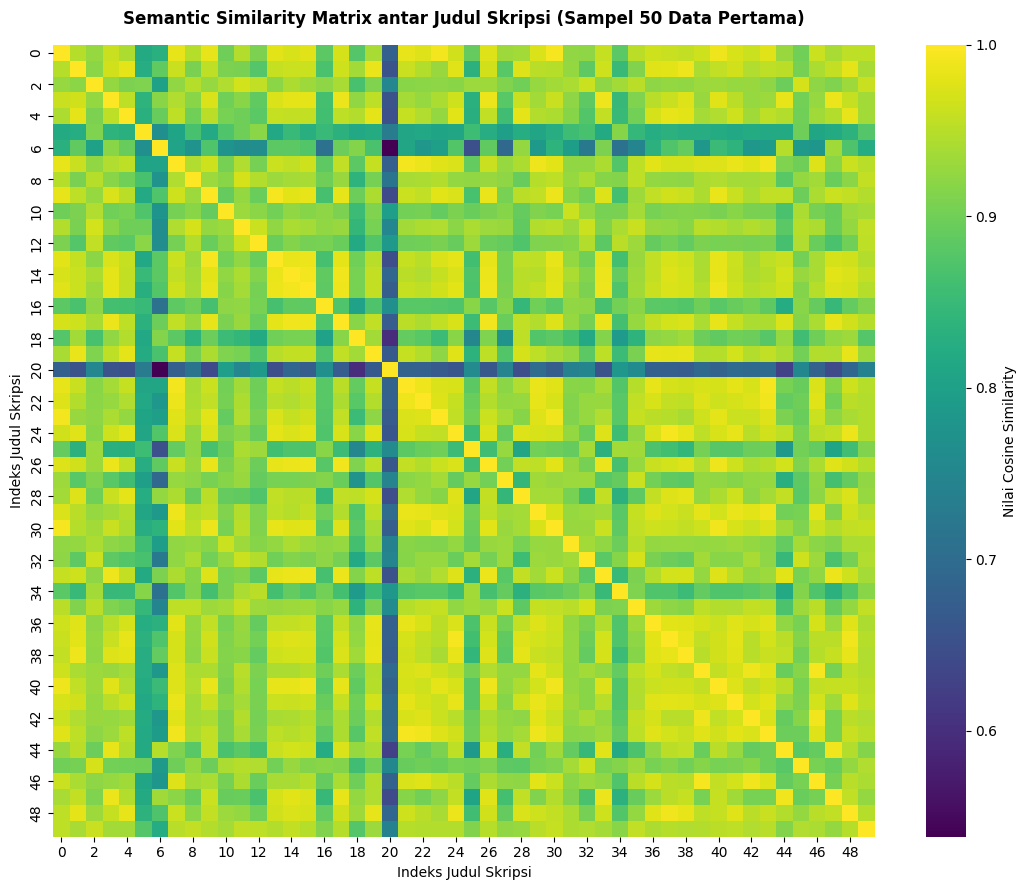


Rata-rata Semantic Similarity dalam Bidang Konsentrasi yang Sama:
 -> TKJ: 0.9419 (94.19%)
 -> RPL: 0.9171 (91.71%)
 -> MULTIMEDIA: 0.9155 (91.55%)


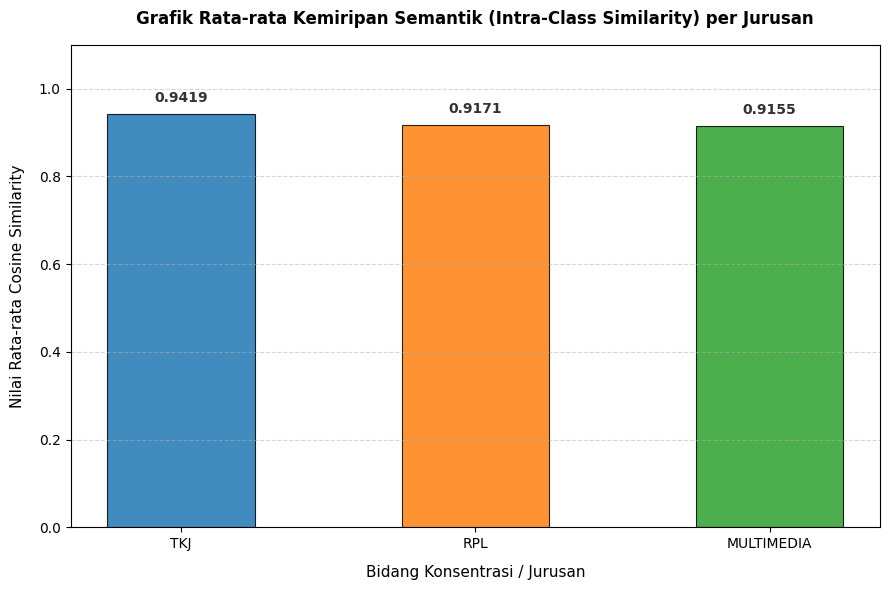

In [54]:
print("\n=== ANALISIS SEMANTIC SIMILARITY (KEMIRIPAN SEMANTIK) ===")

# Kunci data bersih
df_cleaned = df.drop_duplicates(subset=['judul_skripsi']).reset_index(drop=True)
df_cleaned['label'] = df_cleaned['label'].astype(str).str.strip().str.upper()
df_cleaned['label'] = df_cleaned['label'].replace({
    'JARINGAN': 'TKJ', 'tkj': 'TKJ', 'Tkj': 'TKJ',
    'MM': 'MULTIMEDIA', 'mm': 'MULTIMEDIA', 'MULTIMEDIA ': 'MULTIMEDIA'
})

# Pastikan ukuran embeddings dan dataframe sama persis
X_embeddings = embeddings_array[:len(df_cleaned)]
labels_array = df_cleaned['label'].values

# Hitung keseluruhan similarity matrix menggunakan cosine similarity
similarity_matrix = cosine_similarity(X_embeddings)


# OPTIMASI VISUALISASI HEATMAP
sample_size = min(50, len(df_cleaned))
sample_matrix = similarity_matrix[:sample_size, :sample_size]

plt.figure(figsize=(11, 9), dpi=100)
sns.heatmap(sample_matrix, cmap='viridis', cbar_kws={'label': 'Nilai Cosine Similarity'})
plt.title(f'Semantic Similarity Matrix antar Judul Skripsi (Sampel {sample_size} Data Pertama)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Indeks Judul Skripsi', fontsize=10)
plt.ylabel('Indeks Judul Skripsi', fontsize=10)

os.makedirs('output', exist_ok=True)
plt.savefig('output/similarity_matrix.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


# Rata-rata similarity dalam kelas yang sama (Intra-Class Similarity)
categories = ['TKJ', 'RPL', 'MULTIMEDIA']
intra_class_similarity = {}

for category in categories:
    # Gunakan np.where langsung pada array label yang sudah sinkron
    indices = np.where(labels_array == category)[0]

    if len(indices) > 1:
        # Ambil potongan matriks khusus untuk jurusan
        class_sim = similarity_matrix[np.ix_(indices, indices)]

        # Ambil nilai kemiripan antar dokumen
        mask = ~np.eye(class_sim.shape[0], dtype=bool)
        mean_sim = class_sim[mask].mean()
        intra_class_similarity[category] = mean_sim

print("\nRata-rata Semantic Similarity dalam Bidang Konsentrasi yang Sama:")
for category, sim in intra_class_similarity.items():
    print(f" -> {category}: {sim:.4f} ({sim*100:.2f}%)")


#  VISUALISASI DIAGRAM BATANG INTRA-CLASS SIMILARITY
plt.figure(figsize=(9, 6), dpi=100)

# Gunakan warna kontras dengan grafik t-SNE (Biru, Oranye, Hijau)
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = plt.bar(intra_class_similarity.keys(), intra_class_similarity.values(),
               color=colors_bar, alpha=0.85, edgecolor='black', linewidth=0.8, width=0.5)

plt.title('Grafik Rata-rata Kemiripan Semantik (Intra-Class Similarity) per Jurusan', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Bidang Konsentrasi / Jurusan', fontsize=11, labelpad=10)
plt.ylabel('Nilai Rata-rata Cosine Similarity', fontsize=11, labelpad=10)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tambahkan nilai persentase akurat di atas masing-masing bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

plt.savefig('output/intra_class_similarity.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

# **7. Visualisasi Dengan t-SNE dan PCA**


=== RE-DIAGNOSIS & VISUALISASI AMAN PROYEKSI RUANG VEKTOR ===
Jumlah data di Dataframe : 923
Jumlah data di Embeddings: 923
Label: ['MULTIMEDIA' 'RPL' 'TKJ']

Menganalisis persebaran data dengan t-SNE...
 -> Menemukan 368 titik data untuk kategori TKJ di t-SNE
 -> Menemukan 363 titik data untuk kategori RPL di t-SNE
 -> Menemukan 192 titik data untuk kategori MULTIMEDIA di t-SNE


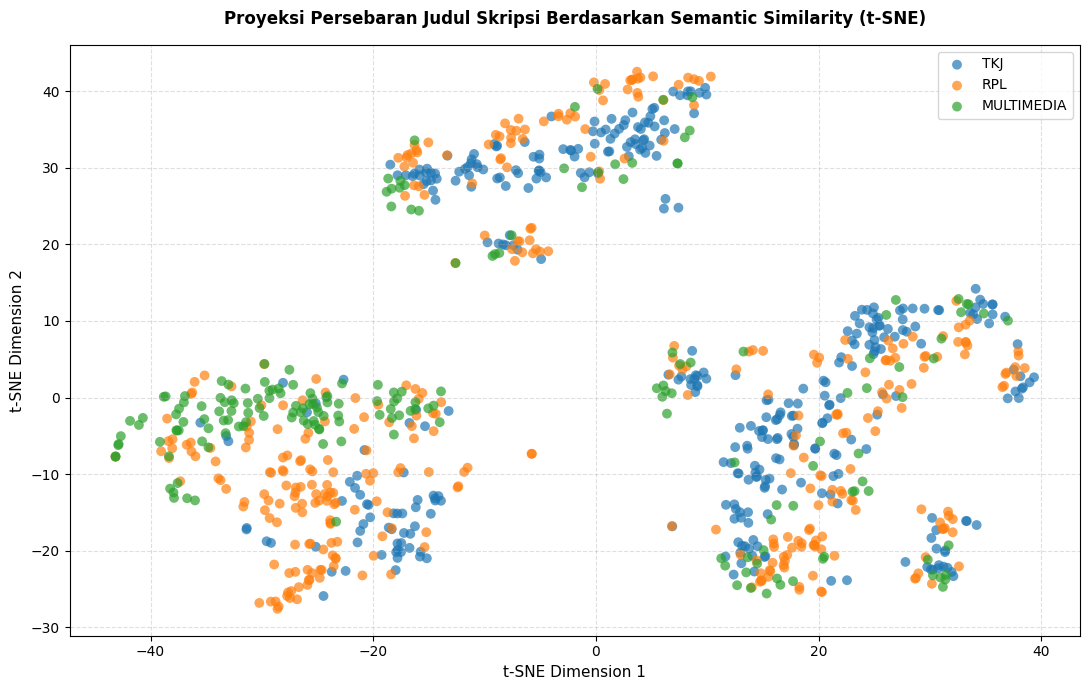


Melakukan reduksi dimensi dengan PCA...
 -> Menemukan 368 titik data untuk kategori TKJ di PCA
 -> Menemukan 363 titik data untuk kategori RPL di PCA
 -> Menemukan 192 titik data untuk kategori MULTIMEDIA di PCA


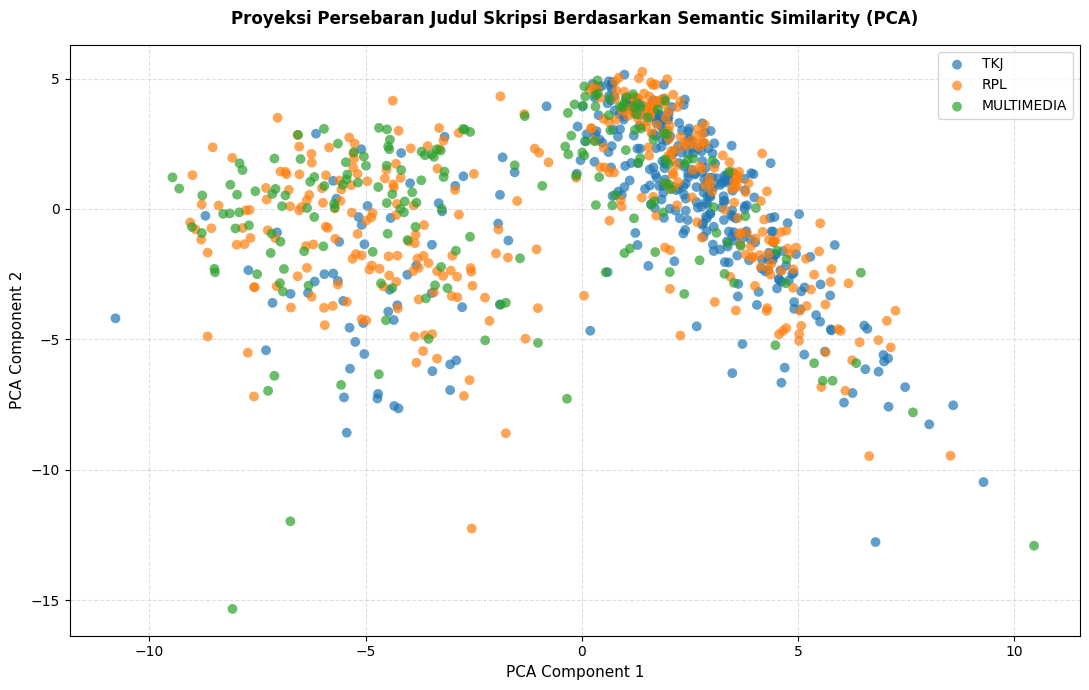

In [55]:
print("\n=== RE-DIAGNOSIS & VISUALISASI AMAN PROYEKSI RUANG VEKTOR ===")

# Ambil data dan bersihkan secara total
df_cleaned = df.drop_duplicates(subset=['judul_skripsi']).reset_index(drop=True)

# Normalisasi awal
df_cleaned['label'] = df_cleaned['label'].astype(str).str.strip().str.upper()
df_cleaned['label'] = df_cleaned['label'].replace({
    'JARINGAN': 'TKJ',
    'tkj': 'TKJ',
    'Tkj': 'TKJ',
    'MM': 'MULTIMEDIA',
    'mm': 'MULTIMEDIA',
    'MULTIMEDIA ': 'MULTIMEDIA'
})

# Ambil paksa embeddings sesuai panjang dataframe
X_embeddings = embeddings_array[:len(df_cleaned)]
labels_array = df_cleaned['label'].values

print("Jumlah data di Dataframe :", len(labels_array))
print("Jumlah data di Embeddings:", len(X_embeddings))
print("Label:", np.unique(labels_array))

categories = ['TKJ', 'RPL', 'MULTIMEDIA']
colors = {'TKJ': '#1f77b4', 'RPL': '#ff7f0e', 'MULTIMEDIA': '#2ca02c'}


# ==================== PROSES & PLOTTING t-SNE ====================
print("\nMenganalisis persebaran data dengan t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_cleaned) - 1))
tsne_result = tsne.fit_transform(X_embeddings)

plt.figure(figsize=(11, 7), dpi=100)

for category in categories:
    indices = np.where(labels_array == category)[0]
    print(f" -> Menemukan {len(indices)} titik data untuk kategori {category} di t-SNE")

    if len(indices) > 0:
        plt.scatter(tsne_result[indices, 0], tsne_result[indices, 1],
                    c=colors[category], label=category, alpha=0.7, edgecolors='none', s=50)

plt.title('Proyeksi Persebaran Judul Skripsi Berdasarkan Semantic Similarity (t-SNE)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('t-SNE Dimension 1', fontsize=11)
plt.ylabel('t-SNE Dimension 2', fontsize=11)
plt.legend(loc='upper right', fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)

os.makedirs('output', exist_ok=True)
plt.savefig('output/tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


# ==================== PROSES & PLOTTING PCA ====================
print("\nMelakukan reduksi dimensi dengan PCA...")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_embeddings)

plt.figure(figsize=(11, 7), dpi=100)

for category in categories:
    indices = np.where(labels_array == category)[0]
    print(f" -> Menemukan {len(indices)} titik data untuk kategori {category} di PCA")

    if len(indices) > 0:
        plt.scatter(pca_result[indices, 0], pca_result[indices, 1],
                    c=colors[category], label=category, alpha=0.7, edgecolors='none', s=50)

plt.title('Proyeksi Persebaran Judul Skripsi Berdasarkan Semantic Similarity (PCA)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('PCA Component 1', fontsize=11)
plt.ylabel('PCA Component 2', fontsize=11)
plt.legend(loc='upper right', fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.savefig('output/pca_visualization.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# **8. Visualisasi Kedekatan Semantik dan Centroid**


=== VISUALISASI KEDEKATAN SEMANTIK ANTAR KATEGORI ===


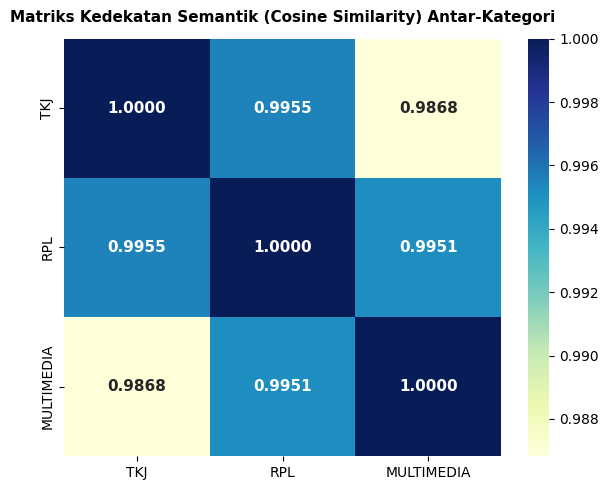

 -> File 'models/category_centroids.pkl' (Centroid Kategori) berhasil dikunci dan disimpan.

Nilai Kedekatan Kosinus Eksak:
 -> Kedekatan TKJ dengan RPL: 0.9955
 -> Kedekatan TKJ dengan MULTIMEDIA: 0.9868
 -> Kedekatan RPL dengan MULTIMEDIA: 0.9951


In [56]:
print("\n=== VISUALISASI KEDEKATAN SEMANTIK ANTAR KATEGORI ===")

# Muat Centroid yang sudah disimpan di cell sebelumnya
if os.path.exists('models/category_centroids.pkl'):
    category_centroids = joblib.load('models/category_centroids.pkl')
    categories = list(category_centroids.keys())

    # Susun matriks koordinat centroid (3 kategori x 768 dimensi)
    centroid_matrix = np.array([category_centroids[cat] for cat in categories])

    # Hitung Cosine Similarity antar-Centroid
    similarity_matrix = cosine_similarity(centroid_matrix)

    # Visualisasikan dalam bentuk Heatmap
    plt.figure(figsize=(6, 5), dpi=100)
    sns.heatmap(similarity_matrix, annot=True, fmt='.4f', cmap='YlGnBu',
                xticklabels=categories, yticklabels=categories, cbar=True,
                annot_kws={"size": 11, "weight": "bold"})

    plt.title('Matriks Kedekatan Semantik (Cosine Similarity) Antar-Kategori', fontsize=11, fontweight='bold', pad=12)
    plt.tight_layout()

    os.makedirs('output', exist_ok=True)
    plt.savefig('output/similarity_matrix.png', dpi=300)
    plt.show()

    # Simpan file koordinat pusat semantik jurusan
    joblib.dump(category_centroids, 'models/category_centroids.pkl')
    print(" -> File 'models/category_centroids.pkl' (Centroid Kategori) berhasil dikunci dan disimpan.")

    # Tampilkan nilai teks untuk referensi tulisan
    print("\nNilai Kedekatan Kosinus Eksak:")
    for i, cat1 in enumerate(categories):
        for j, cat2 in enumerate(categories):
            if i < j:
                print(f" -> Kedekatan {cat1} dengan {cat2}: {similarity_matrix[i,j]:.4f}")


else:
    print("❌ File 'models/category_centroids.pkl' tidak ditemukan. Pastikan cell penyimpanan sudah di-run!")

# **9. Persiapan Data Training dan Testing**

In [57]:
print("\n=== TAHAPAN PERSIAPAN DATA TRAINING & DATA TESTING ===")
print("Membagi data menggunakan skema Stratified Random Sampling (80:20)...")

# Ambil label dari dataframe df yang sudah bersih (923 data)
# Pastikan jumlah baris di df['label'] sama persis dengan baris di embeddings_array
labels_target = df['label'].values

# PROSES SPLIT DATA
# test_size=0.2 artinya 20% untuk data uji (testing) dan 80% untuk data latih (training)
# stratify=labels_target mengunci proporsi sebaran kelas agar seimbang antara data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(
    embeddings_array,
    labels_target,
    test_size=0.2,
    random_state=42,
    stratify=labels_target
)

print(f"\n✔ Proses Split Data Berhasil Selesai:")
print(f" -> Total Basis Dataset Final : {len(embeddings_array)} judul skripsi")
print(f" -> Jumlah Data Training (80%): {len(X_train)} judul skripsi (Untuk melatih AI)")
print(f" -> Jumlah Data Testing  (20%): {len(X_test)} judul skripsi (Untuk ujian/evaluasi AI)")

# Menampilkan distribusi label di data latih dan uji untuk membuktikan efek 'stratify' bekerja
print("\nSebaran Proporsi Kelas di Data Training:")
print(pd.Series(y_train).value_counts(normalize=True).to_string())
print("\nSebaran Proporsi Kelas di Data Testing:")
print(pd.Series(y_test).value_counts(normalize=True).to_string())


=== TAHAPAN PERSIAPAN DATA TRAINING & DATA TESTING ===
Membagi data menggunakan skema Stratified Random Sampling (80:20)...

✔ Proses Split Data Berhasil Selesai:
 -> Total Basis Dataset Final : 923 judul skripsi
 -> Jumlah Data Training (80%): 738 judul skripsi (Untuk melatih AI)
 -> Jumlah Data Testing  (20%): 185 judul skripsi (Untuk ujian/evaluasi AI)

Sebaran Proporsi Kelas di Data Training:
TKJ           0.398374
RPL           0.392954
MULTIMEDIA    0.208672

Sebaran Proporsi Kelas di Data Testing:
TKJ           0.400000
RPL           0.394595
MULTIMEDIA    0.205405


## **10. Hyperparameter Tuning untuk KNN**

In [58]:
warnings.filterwarnings("ignore", category=UserWarning)

print("\n=== OPTIMASI HYPERPARAMETER TUNING KNN ===")
print("Menjalankan GridSearchCV dengan parameter teroptimasi...")

# Inisialisasi model dasar K-NN
knn_base = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [5],
    'weights': ['uniform'],
    'metric': ['minkowski', 'euclidean']
}

grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Proses Fitting ke data training IndoBERT
grid_search_knn.fit(X_train, y_train)

# Ambil model terbaik dan simpan sebagai best_knn
best_knn = grid_search_knn.best_estimator_

print(f"\nParameter KNN terbaik hasil tuning:")
for param, value in grid_search_knn.best_params_.items():
    print(f"  {param}: {value}")
print(f"Akurasi validasi (Rata-rata CV 5-Fold): {grid_search_knn.best_score_:.4f}")

# Evaluasi performa model di data training
y_train_pred_knn = best_knn.predict(X_train)
train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
print(f"Akurasi model di data training: {train_acc_knn:.4f}")



=== OPTIMASI HYPERPARAMETER TUNING KNN ===
Menjalankan GridSearchCV dengan parameter teroptimasi...
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Parameter KNN terbaik hasil tuning:
  metric: minkowski
  n_neighbors: 5
  weights: uniform
Akurasi validasi (Rata-rata CV 5-Fold): 0.7344
Akurasi model di data training: 0.8401


# **11. Hyperparameter Tuning untuk Decision Tree**

In [59]:
warnings.filterwarnings("ignore", category=UserWarning)

print("\n=== OPTIMASI HYPERPARAMETER TUNING DECISION TREE ===")
print("Menjalankan GridSearchCV dengan parameter teroptimasi...")

# Inisialisasi model dasar Decision Tree dengan random_state
dt_base = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'criterion': ['entropy'],
    'max_depth': [5],
    'min_samples_split': [2, 5]
}

# Jalankan GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Proses Fitting ke data training IndoBERT
grid_search_dt.fit(X_train, y_train)

# Ambil model terbaik dan simpan sebagai best_dt
best_dt = grid_search_dt.best_estimator_

# Menampilkan parameter terbaik hasil tuning
print(f"\nParameter Decision Tree terbaik hasil tuning:")
for param, value in grid_search_dt.best_params_.items():
    print(f"  {param}: {value}")
print(f"Akurasi validasi (Rata-rata CV 5-Fold): {grid_search_dt.best_score_:.4f}")

# Evaluasi performa model di data training
y_train_pred_dt = best_dt.predict(X_train)
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
print(f"Akurasi Decision Tree di data training: {train_acc_dt:.4f}")



=== OPTIMASI HYPERPARAMETER TUNING DECISION TREE ===
Menjalankan GridSearchCV dengan parameter teroptimasi...
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Parameter Decision Tree terbaik hasil tuning:
  criterion: entropy
  max_depth: 5
  min_samples_split: 2
Akurasi validasi (Rata-rata CV 5-Fold): 0.6220
Akurasi Decision Tree di data training: 0.8211



# **12. Baseline Model: TF-IDF + Logistic Regression**







=== MENJALANKAN MODEL BASELINE: TF-IDF + LOGISTIC REGRESSION ===
Mengunci data valid untuk model baseline: 923 judul.
Melatih model baseline pada data tekstual...

   HASIL PERFORMA BASELINE (TF-IDF + LR)   
 Data Uji Terproses : 185 judul
 Accuracy           : 0.9135 (91.35%)
 Precision          : 0.9175 (91.75%)
 Recall             : 0.9135 (91.35%)
 F1-Score           : 0.9129 (91.29%)


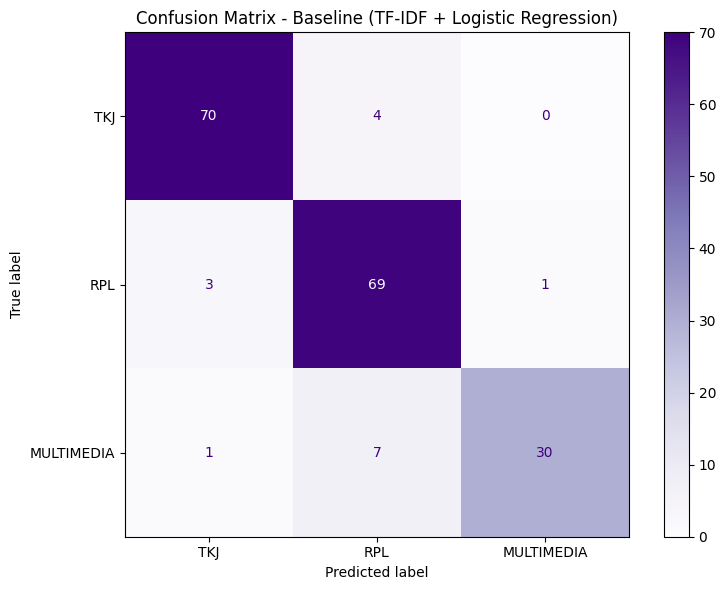

Total data uji Baseline yang masuk ke matriks: 185


In [60]:
print("\n=== MENJALANKAN MODEL BASELINE: TF-IDF + LOGISTIC REGRESSION ===")

# SINKRONISASI DATA
df_cleaned = df.drop_duplicates(subset=['judul_skripsi']).reset_index(drop=True)
print(f"Mengunci data valid untuk model baseline: {len(df_cleaned)} judul.")

# Pembagian data latih dan uji menggunakan teks 'judul_clean' dan label
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    df_cleaned['judul_clean'],
    df_cleaned['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_cleaned['label']
)

# Membangun Pipeline Ekstraksi Fitur Leksikal + Klasifikasi Linear
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# Proses Pelatihan Model Baseline
print("Melatih model baseline pada data tekstual...")
baseline_pipeline.fit(X_train_text, y_train_text)

# Proses Prediksi Data Uji
y_pred_baseline = baseline_pipeline.predict(X_test_text)


# Perhitungan Metrik Evaluasi Komprehensif
baseline_accuracy = accuracy_score(y_test_text, y_pred_baseline)
baseline_precision = precision_score(y_test_text, y_pred_baseline, average='weighted')
baseline_recall = recall_score(y_test_text, y_pred_baseline, average='weighted')
baseline_f1 = f1_score(y_test_text, y_pred_baseline, average='weighted')

print("\n" + "="*45)
print("   HASIL PERFORMA BASELINE (TF-IDF + LR)   ")
print("="*45)
print(f" Data Uji Terproses : {len(y_test_text)} judul")
print(f" Accuracy           : {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f" Precision          : {baseline_precision:.4f} ({baseline_precision*100:.2f}%)")
print(f" Recall             : {baseline_recall:.4f} ({baseline_recall*100:.2f}%)")
print(f" F1-Score           : {baseline_f1:.4f} ({baseline_f1*100:.2f}%)")
print("="*45)

# Membuat Grafik Confusion Matrix Baseline
categories = ['TKJ', 'RPL', 'MULTIMEDIA']
cm_baseline = confusion_matrix(y_test_text, y_pred_baseline, labels=categories)

plt.figure(figsize=(8, 6), dpi=100)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=categories)

disp_baseline.plot(cmap='Purples', ax=plt.gca(), values_format='d')
plt.title('Confusion Matrix - Baseline (TF-IDF + Logistic Regression)')
plt.tight_layout()

# Menyimpan hasil visualisasi matriks baseline
os.makedirs('output', exist_ok=True)
plt.savefig('output/confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total data uji Baseline yang masuk ke matriks: {cm_baseline.sum()}") # Harus mencetak 185

# **13. Evaluasi Model KNN**

---




=== EVALUASI MODEL KNN ===
Akurasi model di data training: 0.8401


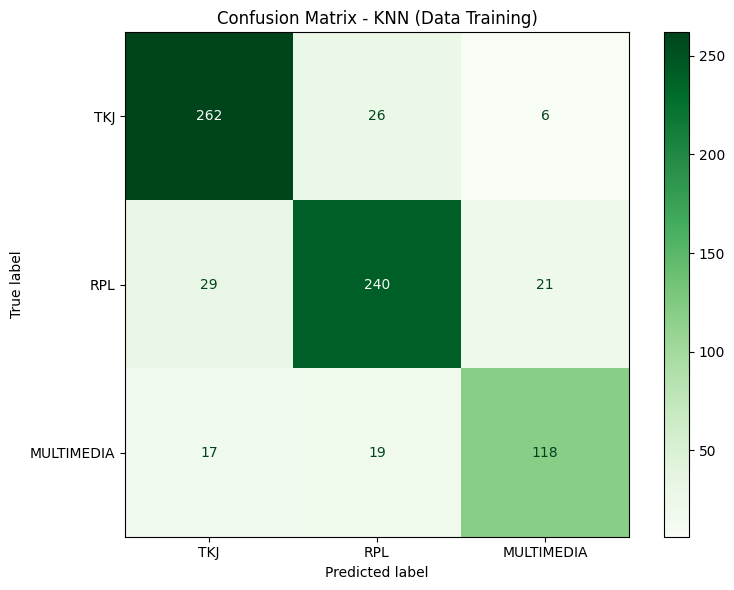


Classification Report untuk KNN (Data Training):
              precision    recall  f1-score   support

         TKJ       0.85      0.89      0.87       294
         RPL       0.84      0.83      0.83       290
  MULTIMEDIA       0.81      0.77      0.79       154

    accuracy                           0.84       738
   macro avg       0.84      0.83      0.83       738
weighted avg       0.84      0.84      0.84       738

Akurasi KNN di data testing: 0.7189


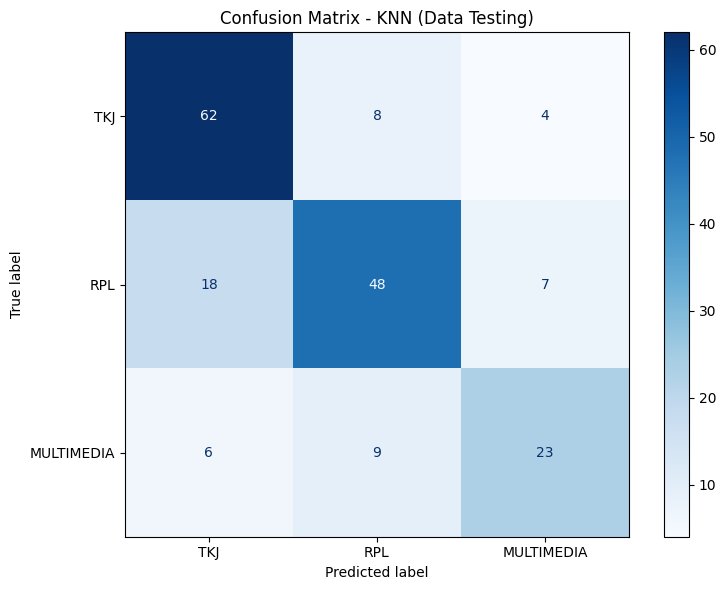


Classification Report untuk KNN (Data Testing):
              precision    recall  f1-score   support

         TKJ       0.72      0.84      0.78        74
         RPL       0.74      0.66      0.70        73
  MULTIMEDIA       0.68      0.61      0.64        38

    accuracy                           0.72       185
   macro avg       0.71      0.70      0.70       185
weighted avg       0.72      0.72      0.72       185

Total data uji KNN yang masuk ke matriks: 185


In [61]:
print("\n=== EVALUASI MODEL KNN ===")

categories = ['TKJ', 'RPL', 'MULTIMEDIA']

# Latih ulang model final dengan K=5 menggunakan X_train dan y_train
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train, y_train)

# EVALUASI DI DATA TRAINING
y_train_pred_knn = knn_final.predict(X_train)
train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
print(f"Akurasi model di data training: {train_acc_knn:.4f}")

train_cm_knn = confusion_matrix(y_train, y_train_pred_knn, labels=categories)
plt.figure(figsize=(8, 6))
disp_train_knn = ConfusionMatrixDisplay(confusion_matrix=train_cm_knn, display_labels=categories)
disp_train_knn.plot(cmap='Greens', ax=plt.gca(), values_format='d')
plt.title('Confusion Matrix - KNN (Data Training)')
plt.tight_layout()
plt.show()

print("\nClassification Report untuk KNN (Data Training):")
print(classification_report(
    y_train,
    y_train_pred_knn,
    labels=categories,
    target_names=categories
))


# EVALUASI DI DATA TESTING
knn_y_pred = knn_final.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_y_pred)
knn_precision = precision_score(y_test, knn_y_pred, average='weighted')
knn_recall = recall_score(y_test, knn_y_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_y_pred, average='weighted')

print(f"Akurasi KNN di data testing: {knn_accuracy:.4f}")

test_cm_knn = confusion_matrix(y_test, knn_y_pred, labels=categories)
plt.figure(figsize=(8, 6))
disp_test_knn = ConfusionMatrixDisplay(confusion_matrix=test_cm_knn, display_labels=categories)
disp_test_knn.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title('Confusion Matrix - KNN (Data Testing)')
plt.tight_layout()
plt.show()

print("\nClassification Report untuk KNN (Data Testing):")
print(classification_report(
    y_test,
    knn_y_pred,
    labels=categories,
    target_names=categories
))

print(f"Total data uji KNN yang masuk ke matriks: {test_cm_knn.sum()}")


# **14. Evaluasi Model Decision Tree**


=== EVALUASI MODEL DECISION TREE ===
Akurasi model di data training: 0.8211


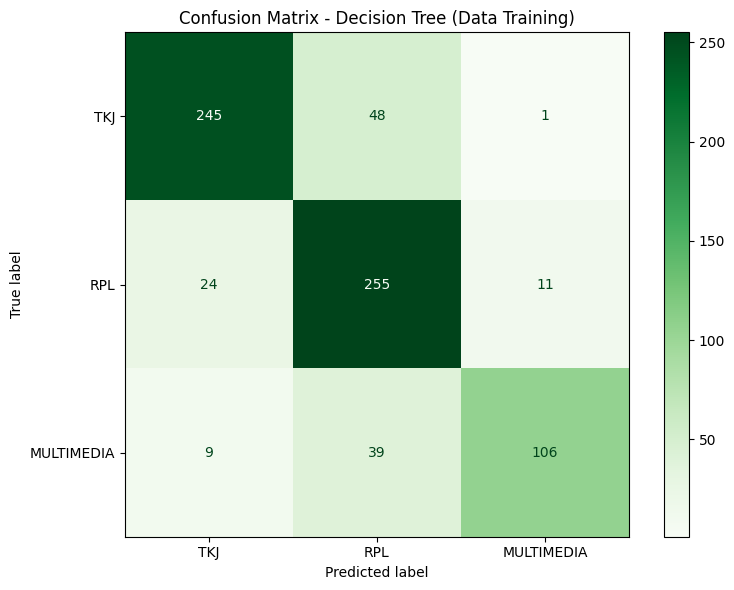


Classification Report untuk Decision Tree (Data Training):
              precision    recall  f1-score   support

         TKJ       0.88      0.83      0.86       294
         RPL       0.75      0.88      0.81       290
  MULTIMEDIA       0.90      0.69      0.78       154

    accuracy                           0.82       738
   macro avg       0.84      0.80      0.81       738
weighted avg       0.83      0.82      0.82       738

Akurasi Decision Tree di data testing: 0.6216


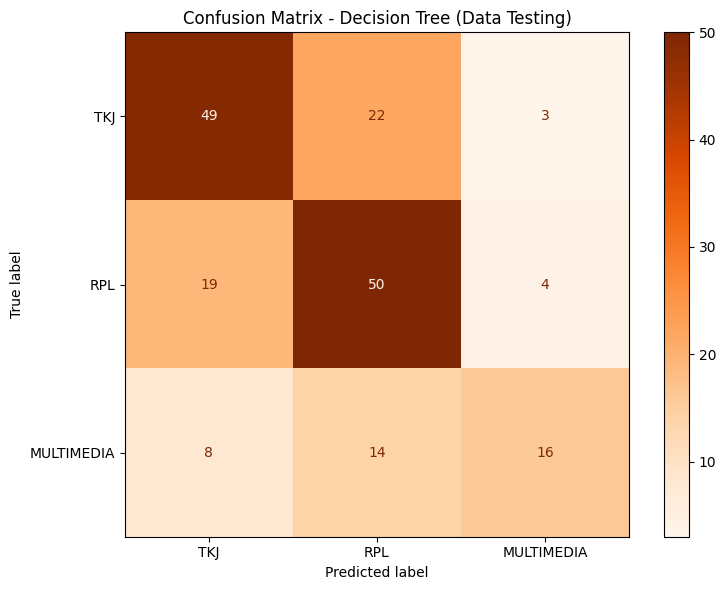


Classification Report untuk Decision Tree (Data Testing):
              precision    recall  f1-score   support

         TKJ       0.64      0.66      0.65        74
         RPL       0.58      0.68      0.63        73
  MULTIMEDIA       0.70      0.42      0.52        38

    accuracy                           0.62       185
   macro avg       0.64      0.59      0.60       185
weighted avg       0.63      0.62      0.62       185

Total data uji Decision Tree yang masuk ke matriks: 185


In [62]:
print("\n=== EVALUASI MODEL DECISION TREE ===")

# Latih ulang model final Decision Tree
dt_final = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_final.fit(X_train, y_train)

# EVALUASI DI DATA TRAINING
y_train_pred_dt = dt_final.predict(X_train)
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
print(f"Akurasi model di data training: {train_acc_dt:.4f}")

train_cm_dt = confusion_matrix(y_train, y_train_pred_dt, labels=categories)
plt.figure(figsize=(8, 6))
disp_train_dt = ConfusionMatrixDisplay(confusion_matrix=train_cm_dt, display_labels=categories)
disp_train_dt.plot(cmap='Greens', ax=plt.gca(), values_format='d')
plt.title('Confusion Matrix - Decision Tree (Data Training)')
plt.tight_layout()
plt.show()

print("\nClassification Report untuk Decision Tree (Data Training):")
print(classification_report(
    y_train,
    y_train_pred_dt,
    labels=categories,
    target_names=categories
))

# EVALUASI DI DATA TESTING
dt_y_pred = dt_final.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_precision = precision_score(y_test, dt_y_pred, average='weighted')
dt_recall = recall_score(y_test, dt_y_pred, average='weighted')
dt_f1 = f1_score(y_test, dt_y_pred, average='weighted')

print(f"Akurasi Decision Tree di data testing: {dt_accuracy:.4f}")

test_cm_dt = confusion_matrix(y_test, dt_y_pred, labels=categories)
plt.figure(figsize=(8, 6))
disp_test_dt = ConfusionMatrixDisplay(confusion_matrix=test_cm_dt, display_labels=categories)
disp_test_dt.plot(cmap='Oranges', ax=plt.gca(), values_format='d')
plt.title('Confusion Matrix - Decision Tree (Data Testing)')
plt.tight_layout()
plt.show()

print("\nClassification Report untuk Decision Tree (Data Testing):")
print(classification_report(
    y_test,
    dt_y_pred,
    labels=categories,
    target_names=categories
))

print(f"Total data uji Decision Tree yang masuk ke matriks: {test_cm_dt.sum()}")


# **15. Evaluasi Performa Model (Data Testing)**


=== TAHAPAN EVALUASI PERFORMA MODEL (DATA TESTING) ===
✔ Akurasi Akhir Model K-NN          : 71.89%
✔ Akurasi Akhir Model Decision Tree : 62.16%


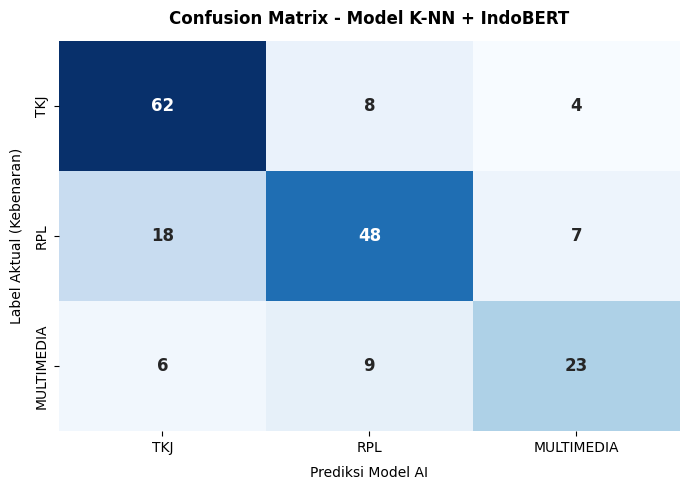

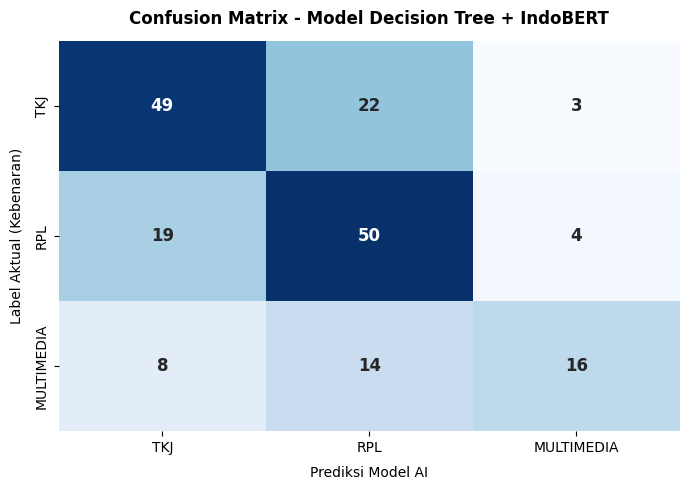


==================== REPORT PERFORMA K-NN ====================
              precision    recall  f1-score   support

         TKJ       0.72      0.84      0.78        74
         RPL       0.74      0.66      0.70        73
  MULTIMEDIA       0.68      0.61      0.64        38

    accuracy                           0.72       185
   macro avg       0.71      0.70      0.70       185
weighted avg       0.72      0.72      0.72       185


================= REPORT PERFORMA DECISION TREE =================
              precision    recall  f1-score   support

         TKJ       0.64      0.66      0.65        74
         RPL       0.58      0.68      0.63        73
  MULTIMEDIA       0.70      0.42      0.52        38

    accuracy                           0.62       185
   macro avg       0.64      0.59      0.60       185
weighted avg       0.63      0.62      0.62       185



In [63]:
print("\n=== TAHAPAN EVALUASI PERFORMA MODEL (DATA TESTING) ===")

# Prediksi Data Testing menggunakan kedua model terbaik
y_pred_knn = best_knn.predict(X_test)
y_pred_dt = best_dt.predict(X_test)

# Hitung Akurasi
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"✔ Akurasi Akhir Model K-NN          : {acc_knn*100:.2f}%")
print(f"✔ Akurasi Akhir Model Decision Tree : {acc_dt*100:.2f}%")

def plot_confusion_matrix(y_true, y_pred, title, filename):
    labels = ['TKJ', 'RPL', 'MULTIMEDIA']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 5), dpi=100)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
                cbar=False, annot_kws={"size": 12, "weight": "bold"})
    plt.title(title, fontsize=12, fontweight='bold', pad=12)
    plt.xlabel('Prediksi Model AI', fontsize=10, labelpad=8)
    plt.ylabel('Label Aktual (Kebenaran)', fontsize=10, labelpad=8)
    plt.tight_layout()

    os.makedirs('output', exist_ok=True)
    plt.savefig(f'output/{filename}', dpi=300)
    plt.show()

# Buat grafik heatmap Confusion Matrix
plot_confusion_matrix(y_test, y_pred_knn, 'Confusion Matrix - Model K-NN + IndoBERT', 'cm_knn.png')
plot_confusion_matrix(y_test, y_pred_dt, 'Confusion Matrix - Model Decision Tree + IndoBERT', 'cm_dt.png')


print("\n" + "="*20 + " REPORT PERFORMA K-NN " + "="*20)
print(classification_report(
    y_test,
    y_pred_knn,
    labels=['TKJ', 'RPL', 'MULTIMEDIA'],
    target_names=['TKJ', 'RPL', 'MULTIMEDIA']
))
print("\n" + "="*17 + " REPORT PERFORMA DECISION TREE " + "="*17)
print(classification_report(
    y_test,
    y_pred_dt,
    labels=['TKJ', 'RPL', 'MULTIMEDIA'],
    target_names=['TKJ', 'RPL', 'MULTIMEDIA']
))

# **16. Analisis Perbandingan Kinerja**


=== MEMBUAT GRAFIK PERBANDINGAN PERFORMA MODEL ===


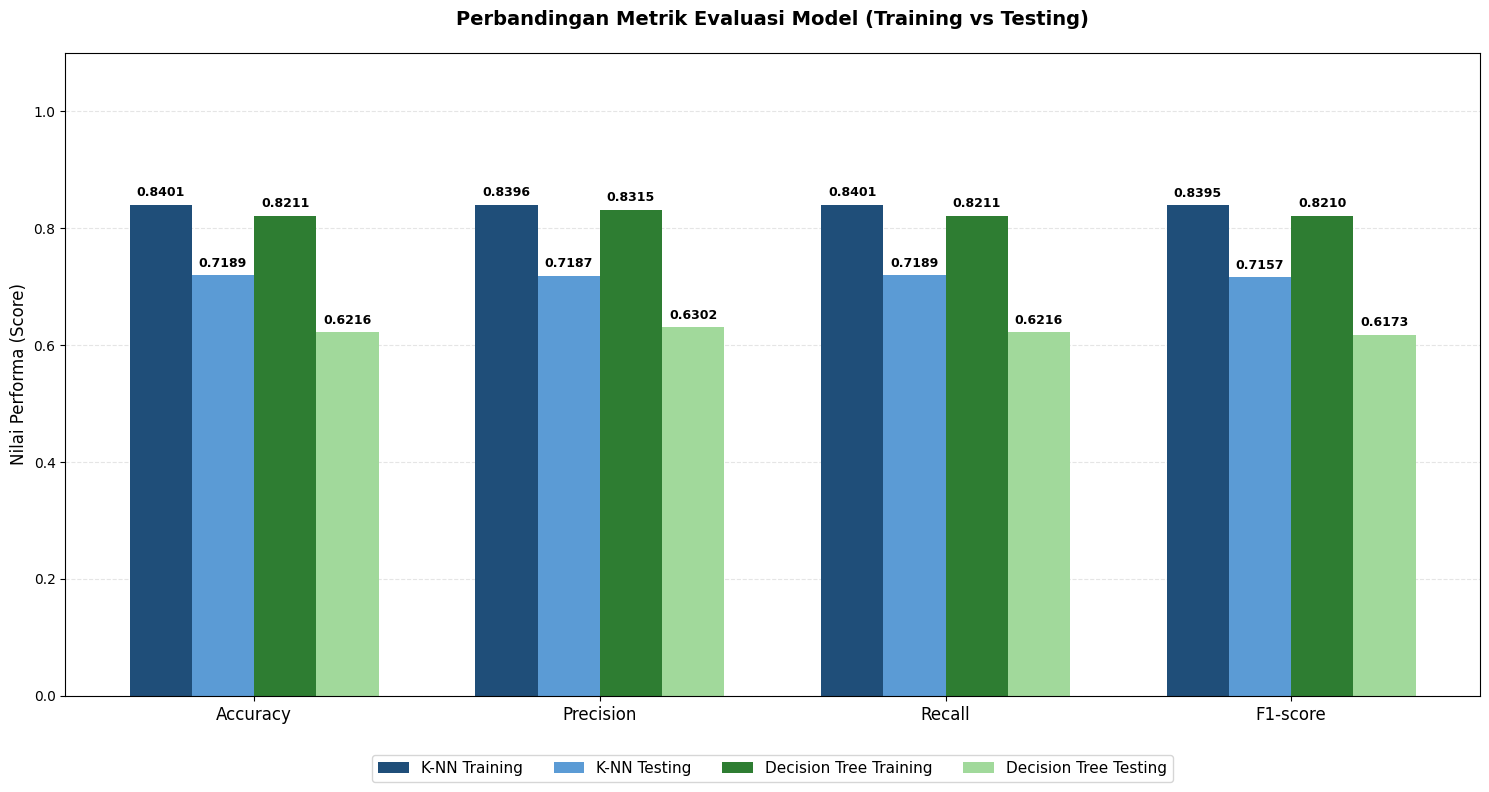

In [64]:
print("\n=== MEMBUAT GRAFIK PERBANDINGAN PERFORMA MODEL ===")

knn_y_train_pred = knn_final.predict(X_train)
dt_y_train_pred = dt_final.predict(X_train)

# Hitung ulang metrik di data training untuk KNN dan Decision Tree
knn_train_accuracy = accuracy_score(y_train, knn_y_train_pred)
knn_train_precision = precision_score(y_train, knn_y_train_pred, average='weighted')
knn_train_recall = recall_score(y_train, knn_y_train_pred, average='weighted')
knn_train_f1 = f1_score(y_train, knn_y_train_pred, average='weighted')

dt_train_accuracy = accuracy_score(y_train, dt_y_train_pred)
dt_train_precision = precision_score(y_train, dt_y_train_pred, average='weighted')
dt_train_recall = recall_score(y_train, dt_y_train_pred, average='weighted')
dt_train_f1 = f1_score(y_train, dt_y_train_pred, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

knn_train_scores = [knn_train_accuracy, knn_train_precision, knn_train_recall, knn_train_f1]
dt_train_scores = [dt_train_accuracy, dt_train_precision, dt_train_recall, dt_train_f1]

knn_test_scores = [knn_accuracy, knn_precision, knn_recall, knn_f1]
dt_test_scores = [dt_accuracy, dt_precision, dt_recall, dt_f1]

# Pengaturan dimensi grafik batang
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(15, 8), dpi=100)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

rects1 = ax.bar(x - 1.5*width, knn_train_scores, width, label='K-NN Training', color='#1f4e79')   # Dark Blue/Navy
rects2 = ax.bar(x - 0.5*width, knn_test_scores, width, label='K-NN Testing', color='#5b9bd5')     # Light Blue
rects3 = ax.bar(x + 0.5*width, dt_train_scores, width, label='Decision Tree Training', color='#2e7d32') # Emerald Green
rects4 = ax.bar(x + 1.5*width, dt_test_scores, width, label='Decision Tree Testing', color='#a1d99b')  # Soft Green

# Kustomisasi teks judul dan label sumbu grafik
ax.set_title('Perbandingan Metrik Evaluasi Model (Training vs Testing)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Nilai Performa (Score)', fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=11, frameon=True)

# Fungsi kustom untuk mencetak angka nilai di atas ujung batang secara presisi
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')

add_labels(rects1)
add_labels(rects2)
add_labels(rects3)
add_labels(rects4)

os.makedirs('output', exist_ok=True)

plt.tight_layout()
plt.savefig('output/performance_comparison_train_test.png', dpi=300, bbox_inches='tight')
plt.show()

# **17. Analisis Sensitivitas KNN Terhadap Jumlah Neighbors**


=== ANALISIS SENSITIVITAS KNN TERHADAP JUMLAH NEIGHBORS ===
Mengunci data valid untuk analisis sensitivitas: 923 judul.
k= 1 -> Training Accuracy = 1.0000 | Testing Accuracy = 0.7027
k= 3 -> Training Accuracy = 0.8713 | Testing Accuracy = 0.7351
k= 5 -> Training Accuracy = 0.8401 | Testing Accuracy = 0.7189
k= 7 -> Training Accuracy = 0.8089 | Testing Accuracy = 0.7189
k= 9 -> Training Accuracy = 0.7873 | Testing Accuracy = 0.6811
k=11 -> Training Accuracy = 0.7873 | Testing Accuracy = 0.6649
k=13 -> Training Accuracy = 0.7696 | Testing Accuracy = 0.6703
k=15 -> Training Accuracy = 0.7602 | Testing Accuracy = 0.6811
k=17 -> Training Accuracy = 0.7588 | Testing Accuracy = 0.6919
k=19 -> Training Accuracy = 0.7331 | Testing Accuracy = 0.6703


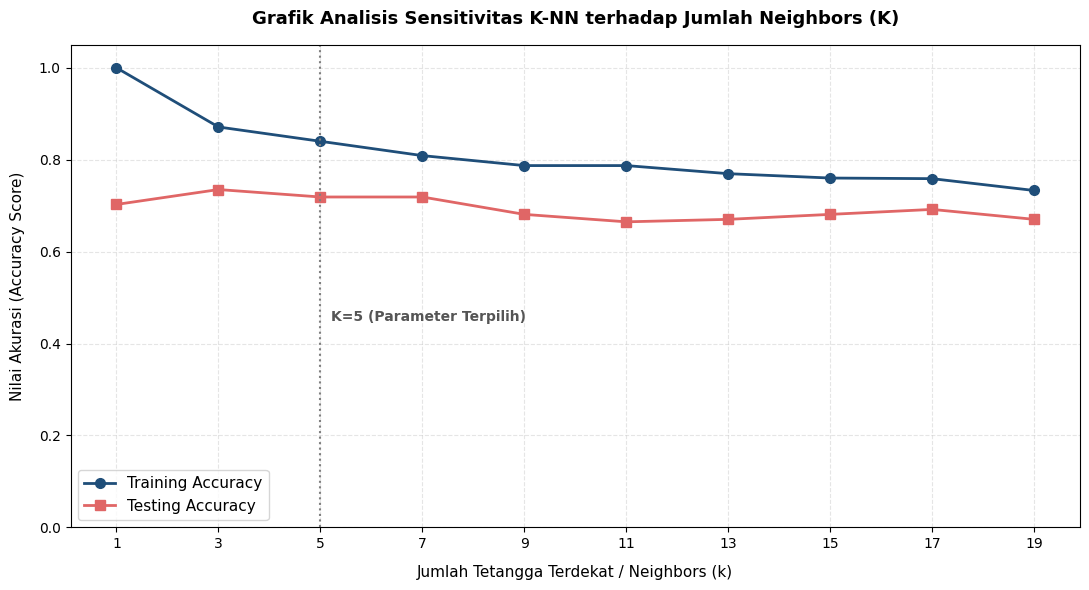

In [65]:
print("\n=== ANALISIS SENSITIVITAS KNN TERHADAP JUMLAH NEIGHBORS ===")

df_cleaned = df.drop_duplicates(subset=['judul_skripsi']).reset_index(drop=True)
print(f"Mengunci data valid untuk analisis sensitivitas: {len(df_cleaned)} judul.")

# Ambil fitur semantik dan target label dari basis data
X = embeddings_array
y = df_cleaned['label'].values

# Split data secara proporsional menggunakan parameter stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Definisikan interval nilai K ganjil dari 1 sampai 19
k_values = list(range(1, 21, 2))  # k = 1, 3, 5, ..., 19
train_scores = []
test_scores = []

# Proses perulangan pengujian nilai K
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Hitung akurasi di data training
    train_acc = knn.score(X_train, y_train)
    train_scores.append(train_acc)

    # Hitung akurasi di data testing
    test_acc = knn.score(X_test, y_test)
    test_scores.append(test_acc)

    print(f"k={k:2d} -> Training Accuracy = {train_acc:.4f} | Testing Accuracy = {test_acc:.4f}")


# VISUALISASI GRAFIK SENSITIVITAS
plt.figure(figsize=(11, 6), dpi=100)
plt.plot(k_values, train_scores, marker='o', markersize=7, linewidth=2, label='Training Accuracy', color='#1f4e79') # Navy
plt.plot(k_values, test_scores, marker='s', markersize=7, linewidth=2, label='Testing Accuracy', color='#e06666')  # Coral/Red

# Tambahkan garis penanda vertikal putus-putus pada K=5
plt.axvline(x=5, color='#7f7f7f', linestyle=':', linewidth=1.5)
plt.text(5.2, 0.45, 'K=5 (Parameter Terpilih)', color='#555555', fontsize=10, fontweight='bold')

# Pengaturan teks judul dan sumbu grafik
plt.title('Grafik Analisis Sensitivitas K-NN terhadap Jumlah Neighbors (K)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Jumlah Tetangga Terdekat / Neighbors (k)', fontsize=11, labelpad=10)
plt.ylabel('Nilai Akurasi (Accuracy Score)', fontsize=11, labelpad=10)
plt.xticks(k_values, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)
plt.grid(axis='both', linestyle='--', alpha=0.5, color='#cccccc')
plt.legend(loc='lower left', fontsize=11, frameon=True, shadow=False)

os.makedirs('output', exist_ok=True)

plt.tight_layout()
plt.savefig('output/knn_sensitivity_train_test.png', dpi=300, bbox_inches='tight')
plt.show()

# **18. Analisis Sensitivitas Decision Tree Terhadap Max Depth**


=== ANALISIS SENSITIVITAS DECISION TREE TERHADAP MAX DEPTH ===
max_depth= 1 -> Training Accuracy = 0.5068 | Testing Accuracy = 0.4973
max_depth= 2 -> Training Accuracy = 0.6504 | Testing Accuracy = 0.5730
max_depth= 3 -> Training Accuracy = 0.7019 | Testing Accuracy = 0.6324
max_depth= 5 -> Training Accuracy = 0.8211 | Testing Accuracy = 0.6216
max_depth= 7 -> Training Accuracy = 0.9634 | Testing Accuracy = 0.6378
max_depth=10 -> Training Accuracy = 1.0000 | Testing Accuracy = 0.6324
max_depth=15 -> Training Accuracy = 1.0000 | Testing Accuracy = 0.6324
max_depth=20 -> Training Accuracy = 1.0000 | Testing Accuracy = 0.6324
max_depth=25 -> Training Accuracy = 1.0000 | Testing Accuracy = 0.6324
max_depth=30 -> Training Accuracy = 1.0000 | Testing Accuracy = 0.6324


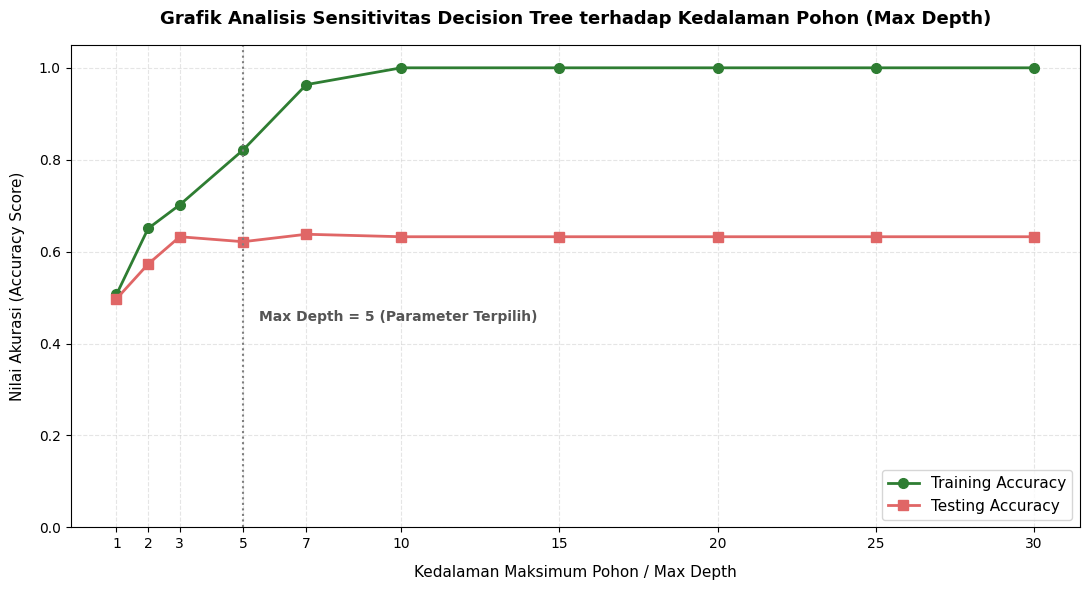

In [66]:
print("\n=== ANALISIS SENSITIVITAS DECISION TREE TERHADAP MAX DEPTH ===")

df_cleaned = df.drop_duplicates(subset=['judul_skripsi']).reset_index(drop=True)

X = embeddings_array
y = df_cleaned['label'].values

# Split data secara proporsional
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Definisikan interval nilai Max Depth yang akan diuji
depth_values = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
depth_train_scores = []
depth_test_scores = []

# Proses perulangan pengujian tingkat kedalaman pohon
for depth in depth_values:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    train_score = accuracy_score(y_train, dt.predict(X_train))
    test_score = accuracy_score(y_test, dt.predict(X_test))

    depth_train_scores.append(train_score)
    depth_test_scores.append(test_score)
    print(f"max_depth={depth:2d} -> Training Accuracy = {train_score:.4f} | Testing Accuracy = {test_score:.4f}")


# VISUALISASI GRAFIK SENSITIVITAS
plt.figure(figsize=(11, 6), dpi=100)

# Memplot nilai depth_values secara langsung pada sumbu X agar skala interval akurat
plt.plot(depth_values, depth_train_scores, marker='o', markersize=7, linewidth=2, label='Training Accuracy', color='#2e7d32') # Emerald Green
plt.plot(depth_values, depth_test_scores, marker='s', markersize=7, linewidth=2, label='Testing Accuracy', color='#e06666')  # Coral/Red

# Tambahkan garis penanda vertikal putus-putus pada max_depth=5 sesuai parameter terpilih
plt.axvline(x=5, color='#7f7f7f', linestyle=':', linewidth=1.5)
plt.text(5.5, 0.45, 'Max Depth = 5 (Parameter Terpilih)', color='#555555', fontsize=10, fontweight='bold')

# Pengaturan teks judul dan sumbu grafik
plt.title('Grafik Analisis Sensitivitas Decision Tree terhadap Kedalaman Pohon (Max Depth)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Kedalaman Maksimum Pohon / Max Depth', fontsize=11, labelpad=10)
plt.ylabel('Nilai Akurasi (Accuracy Score)', fontsize=11, labelpad=10)

# Atur ticks agar semua nilai di list depth_values tercetak jelas di sumbu X
plt.xticks(depth_values, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)
plt.grid(axis='both', linestyle='--', alpha=0.5, color='#cccccc')

# Letakkan kotak keterangan
plt.legend(loc='lower right', fontsize=11, frameon=True)

os.makedirs('output', exist_ok=True)

plt.tight_layout()
plt.savefig('output/dt_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

# **19. Menyimpan Model dan Hasil**

In [81]:
print("\n=== TAHAPAN SERIAlISASI / PENYIMPANAN MODEL UTAMA ===")

os.makedirs('models', exist_ok=True)

# SIMPAN MODEL KLASIFIKASI TERBAIK
try:
    joblib.dump(best_knn, 'models/best_knn_model.pkl')
    print(" -> File 'models/best_knn_model.pkl' berhasil disimpan.")
except NameError:
    print(" ❌ Peringatan: Variabel 'best_knn' belum dideklarasikan di cell atas!")

try:
    joblib.dump(best_dt, 'models/best_decision_tree_model.pkl')
    print(" -> File 'models/best_decision_tree_model.pkl' berhasil disimpan.")
except NameError:
    print(" ❌ Peringatan: Variabel 'best_dt' belum dideklarasikan di cell atas!")


# Simpan centroid per kategori secara sinkron
# Kunci kategori standar: TKJ, RPL, MULTIMEDIA
categories_fixed = ['TKJ', 'RPL', 'MULTIMEDIA']
category_centroids = {}

# Ambil array label yang sudah sinkron dengan matriks embedding
labels_array = df['label'].values

for category in categories_fixed:
    # Cari indeks baris menggunakan numpy
    indices = np.where(labels_array == category)[0]

    if len(indices) > 0:
        category_embeddings = embeddings_array[indices]
        # Hitung rata-rata posisi koordinat vektor semantik (Centroid) di ruang 768 dimensi
        centroid = category_embeddings.mean(axis=0)
        category_centroids[category] = centroid


# Simpan file koordinat pusat semantik jurusan
joblib.dump(category_centroids, 'models/category_centroids.pkl')
print(" -> File 'models/category_centroids.pkl' (Centroid Kategori) berhasil dikunci dan disimpan.")


print("\n=== REKAPITULASI PROSES EKSPERIMEN ===")
try:
    # Menghitung selisih waktu jika start_time ada
    total_time = time.time() - start_time
    print(f" -> Total waktu eksekusi sistem: {total_time:.2f} detik ({total_time/60:.2f} menit)")
except NameError:
    # Pengaman jika Anda running cell ini terpisah tanpa start_time
    print(" -> Waktu eksekusi tidak dapat dihitung secara akurat karena 'start_time' di cell awal belum di-run.")

print("\n✔ [SUKSES] SELURUH PROSES ANALISIS SKRIPSI TELAH SELESAI!")
print(" -> Semua file grafik (.png) tersimpan dengan aman di folder: 'output/'")
print(" -> Semua file model kecerdasan buatan (.pkl & .npy) terkunci di folder: 'models/'")


=== TAHAPAN SERIAlISASI / PENYIMPANAN MODEL UTAMA ===
 -> File 'models/best_knn_model.pkl' berhasil disimpan.
 -> File 'models/best_decision_tree_model.pkl' berhasil disimpan.
 -> File 'models/category_centroids.pkl' (Centroid Kategori) berhasil dikunci dan disimpan.

=== REKAPITULASI PROSES EKSPERIMEN ===
 -> Total waktu eksekusi sistem: 1492.59 detik (24.88 menit)

✔ [SUKSES] SELURUH PROSES ANALISIS SKRIPSI TELAH SELESAI!
 -> Semua file grafik (.png) tersimpan dengan aman di folder: 'output/'
 -> Semua file model kecerdasan buatan (.pkl & .npy) terkunci di folder: 'models/'
